# Derivatives and Gradients

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

In [4]:
# Numerical derivative — no formula needed
# (f(x + tiny) - f(x - tiny)) / (2 * tiny)

def numerical_derivative(f, x, tiny=1e-5):
    return (f(x + tiny) - f(x - tiny)) / (2 * tiny)

In [3]:
# test on f(x) = x²  — true derivative is 2x
f = lambda x: x**2
x = 3.0
print("Our derivative:  ", numerical_derivative(f, x))
print("True derivative: ", 2 * x)  

Our derivative:   6.000000000039306
True derivative:  6.0


Derivative = slope of the function at a point.
Positive derivative → function is going up at this point.
Negative derivative → function is going down.
Zero derivative → we're at a minimum, maximum, or saddle point.

In ML: we want to find where the loss function has derivative = 0.
That's the minimum, where the model is best.

### Visualizing Derivatives

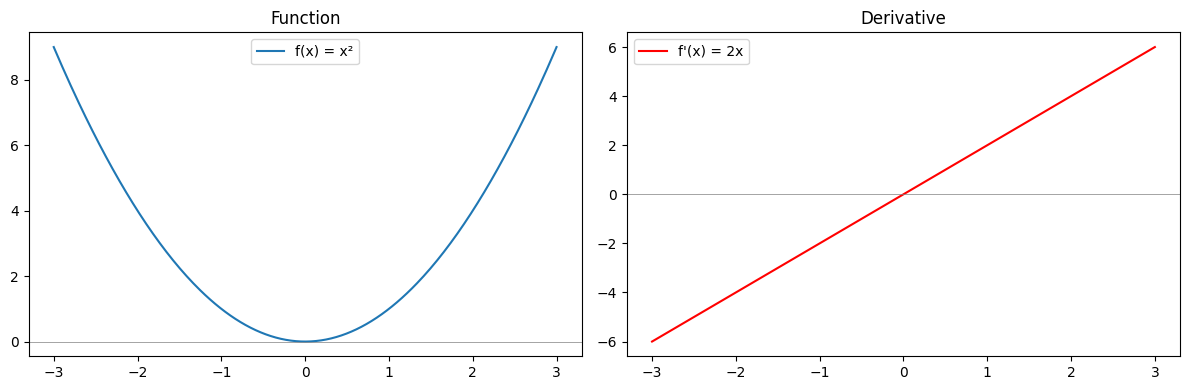

In [5]:
x = np.linspace(-3,3,300)
y = x**2

dy = 2*x

fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].plot(x, y, label='f(x) = x²')
axes[0].set_title('Function')
axes[0].legend()
axes[0].axhline(0, color='gray', linewidth=0.5)

axes[1].plot(x, dy, label="f'(x) = 2x", color='red')
axes[1].set_title('Derivative')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].legend()

plt.tight_layout()
plt.show()

### Partial derivatives

In [8]:
# f(x, y) = x² + 3y²
# ∂f/∂x = 2x   (treat y as constant)
# ∂f/∂y = 6y   (treat x as constant)

def f(x,y):
    return x**2+ 3*y**2

x, y = 2.0, 1.0

#partial derivative wrt x: change x, y is fixed
df_dx = numerical_derivative(lambda x_: f(x_, y), x)

# partial w.r.t. y: nudge y, hold x fixed
df_dy = numerical_derivative(lambda y_: f(x, y_), y)

print("∂f/∂x:", df_dx, "  true:", 2*x)
print("∂f/∂y:", df_dy, "  true:", 6*y)

∂f/∂x: 4.000000000026205   true: 4.0
∂f/∂y: 5.999999999994897   true: 6.0


Partial derivative = derivative w.r.t. one variable, others held fixed.
A neural network loss function has millions of variables (weights).
We compute the partial derivative w.r.t. every single weight.
That collection of all partial derivatives is called the gradient.

### The Gradient

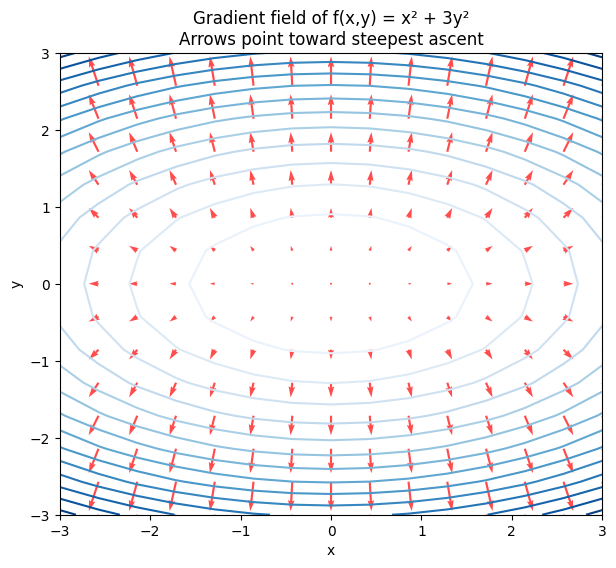

In [13]:
# gradient = vector of all partial derivatives
# points in direction of steepest ascent

def gradient_f(x,y):
    # f(x,y) = x**2 + 3*y**2
    df_dx = 2*x
    df_dy = 6*y
    return np.array([df_dx, df_dy])

# visualize gradient field
x_vals = np.linspace(-3, 3, 15)
y_vals = np.linspace(-3, 3, 15)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals) #This creates every possible combination of x and y.

U = 2 * X_grid        # ∂f/∂x at every point
V = 6 * Y_grid        # ∂f/∂y at every point

plt.figure(figsize=(7, 6))
plt.contour(X_grid, Y_grid, X_grid**2 + 3*Y_grid**2, levels=15, cmap='Blues')
plt.quiver(X_grid, Y_grid, U, V, alpha=0.7, color='red')
plt.title('Gradient field of f(x,y) = x² + 3y²\nArrows point toward steepest ascent')
plt.xlabel('x')
plt.ylabel('y')
plt.show()